# Optimisation de LightGBM et du seuil métier

Ce notebook optimise LightGBM en comparant plusieurs combinaisons d'hyperparamètres et plusieurs seuils de décision. Le couple qui minimise le coût métier moyen 10 × FN + FP sur les 5 folds sera retenu.

## Chargement et séparation des données

In [1]:
# ---------- Bibliothèques ----------
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay, confusion_matrix, f1_score,
    recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_validate, train_test_split,
)
from sklearn.pipeline import Pipeline

# ---------- Configuration des données ----------
DATA_PATH = Path("../data/processed/application_train_final_encoded.csv")
ID_COLUMN = "SK_ID_CURR"
TARGET_COLUMN = "TARGET"
RANDOM_STATE = 42

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Fichier introuvable : {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
required_columns = {ID_COLUMN, TARGET_COLUMN}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Colonnes obligatoires absentes : {sorted(missing_columns)}")

X = df.drop(columns=[ID_COLUMN, TARGET_COLUMN])
y = df[TARGET_COLUMN]

# 80 % servent à l'entraînement et à la validation croisée ; 20 % restent intouchés pour l'évaluation finale.
X_train, X_final, y_train, y_final = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Entraînement : {len(X_train):,} lignes")
print(f"Évaluation finale : {len(X_final):,} lignes")
print(f"Poids de la classe 1 : {SCALE_POS_WEIGHT:.2f}")

Entraînement : 246,008 lignes
Évaluation finale : 61,502 lignes
Poids de la classe 1 : 11.39


## Preprocessing et coût métier

L'imputation médiane est apprise uniquement pendant l'entraînement. Le coût métier pénalise un faux négatif dix fois plus qu'un faux positif.

In [2]:
# ---------- Pipeline LightGBM ----------
def create_lightgbm_pipeline(model_params):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", LGBMClassifier(**model_params)),
    ])


# ---------- Coût métier ----------
FN_COST = 10
FP_COST = 1
THRESHOLDS = [value / 100 for value in range(10, 91, 5)]

def business_cost(y_true, y_pred):
    """Calcule le coût métier : 10 × FN + 1 × FP."""
    _, fp, fn, _ = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return FN_COST * fn + FP_COST * fp


# ---------- Métriques d'évaluation ----------
def evaluate_predictions(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()
    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "recall": recall_score(y_true, y_pred, pos_label=1),
        "f1_score": f1_score(y_true, y_pred, pos_label=1),
        "fn": int(fn),
        "fp": int(fp),
        "tn": int(tn),
        "tp": int(tp),
        "business_cost": int(business_cost(y_true, y_pred)),
    }

## Sélection de la meilleure version du dataset

Les transformations proposées lors de l'analyse (voir conclusion Notebook 04) précédente sont comparées dans des conditions identiques afin de retenir la version des données donnant le meilleur coût métier avant l'optimisation des hyperparamètres. Les sept colonnes strictement constantes sont d'abord retirées de toutes les versions. Le même LightGBM pondéré, le même seuil de 0,5 et les mêmes cinq folds sont utilisés pour les cinq versions, dont une version `all_transformations` qui cumule toutes les transformations testées.

In [3]:
# ---------- Colonnes issues de l'analyse du notebook 04 ----------
CONSTANT_COLUMNS = [
    "CODE_GENDER__nan",
    "NAME_INCOME_TYPE__nan",
    "NAME_EDUCATION_TYPE__nan",
    "NAME_FAMILY_STATUS__nan",
    "NAME_HOUSING_TYPE__nan",
    "WEEKDAY_APPR_PROCESS_START__nan",
    "ORGANIZATION_TYPE__nan",
]
QUASI_CONSTANT_COLUMNS = [
    "WEEKDAY_APPR_PROCESS_START__nan", "ORGANIZATION_TYPE__nan",
    "NAME_FAMILY_STATUS__nan", "CODE_GENDER__nan",
    "NAME_INCOME_TYPE__nan", "NAME_EDUCATION_TYPE__nan",
    "NAME_HOUSING_TYPE__nan", "OBS_30_CNT_SOCIAL_CIRCLE_ANOMALOUS",
    "OBS_60_CNT_SOCIAL_CIRCLE_ANOMALOUS", "FLAG_MOBIL",
    "FLAG_DOCUMENT_12", "NAME_FAMILY_STATUS__Unknown",
    "CODE_GENDER__XNA", "NAME_INCOME_TYPE__Maternity leave",
    "FLAG_DOCUMENT_10", "NAME_INCOME_TYPE__Businessman",
    "FLAG_DOCUMENT_2", "NAME_INCOME_TYPE__Student",
    "NAME_INCOME_TYPE__Unemployed",
    "ORGANIZATION_TYPE__Industry: type 8", "FLAG_DOCUMENT_4",
    "ORGANIZATION_TYPE__Trade: type 5", "FLAG_DOCUMENT_7",
    "ORGANIZATION_TYPE__Trade: type 4",
    "ORGANIZATION_TYPE__Industry: type 13", "FLAG_DOCUMENT_17",
    "ORGANIZATION_TYPE__Religion", "FLAG_DOCUMENT_21",
    "ORGANIZATION_TYPE__Industry: type 10",
    "ORGANIZATION_TYPE__Industry: type 6", "FLAG_DOCUMENT_20",
    "NAME_EDUCATION_TYPE__Academic degree", "FLAG_DOCUMENT_19",
    "ORGANIZATION_TYPE__Transport: type 1",
    "ORGANIZATION_TYPE__Cleaning",
    "NAME_TYPE_SUITE__Group of people",
    "ORGANIZATION_TYPE__Legal Services",
]
BUREAU_DPD_COLUMNS = [
    "BUREAU_EVER_SEVERE_DPD",
    "BUREAU_EVER_RECENT_DPD_12M",
]

available_constant_columns = [
    column for column in CONSTANT_COLUMNS if column in X_train.columns
]
X_train_base = X_train.drop(columns=available_constant_columns)
X_final_base = X_final.drop(columns=available_constant_columns)

available_quasi_columns = [
    column for column in QUASI_CONSTANT_COLUMNS if column in X_train_base.columns
]
available_bureau_columns = [
    column for column in BUREAU_DPD_COLUMNS if column in X_train_base.columns
]

# ---------- Version avec feature engineering ----------
X_train_engineered = X_train_base.copy()
X_final_engineered = X_final_base.copy()
engineered_datasets = (X_train_engineered, X_final_engineered)

RATIO_FEATURES = {
    "CREDIT_INCOME_RATIO": ("AMT_CREDIT", "AMT_INCOME_TOTAL"),
    "ANNUITY_INCOME_RATIO": ("AMT_ANNUITY", "AMT_INCOME_TOTAL"),
    "INCOME_PER_PERSON": ("AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS"),
    "CREDIT_GOODS_RATIO": ("AMT_CREDIT", "AMT_GOODS_PRICE"),
    "ANNUITY_CREDIT_RATIO": ("AMT_ANNUITY", "AMT_CREDIT"),
    "EMPLOYED_AGE_RATIO": ("DAYS_EMPLOYED", "DAYS_BIRTH"),
    "BUREAU_DEBT_INCOME_RATIO": ("BUREAU_DEBT_SUM", "AMT_INCOME_TOTAL"),
}
EXT_SOURCE_COLUMNS = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

created_features = []
existing_features = []
skipped_features = []
used_source_columns = set()

for feature, (numerator, denominator) in RATIO_FEATURES.items():
    required = {numerator, denominator}
    if feature in X_train_base.columns:
        existing_features.append(feature)
        used_source_columns.update(required)
    elif required.issubset(X_train_base.columns):
        for dataset in engineered_datasets:
            dataset[feature] = dataset[numerator] / dataset[denominator].replace(0, np.nan)
        created_features.append(feature)
        used_source_columns.update(required)
    else:
        skipped_features.append(feature)

for feature in ["EXT_SOURCE_MEAN", "EXT_SOURCE_MISSING_COUNT"]:
    if feature in X_train_base.columns:
        existing_features.append(feature)
        used_source_columns.update(EXT_SOURCE_COLUMNS)
    elif set(EXT_SOURCE_COLUMNS).issubset(X_train_base.columns):
        for dataset in engineered_datasets:
            if feature == "EXT_SOURCE_MEAN":
                dataset[feature] = dataset[EXT_SOURCE_COLUMNS].mean(axis=1)
            else:
                dataset[feature] = dataset[EXT_SOURCE_COLUMNS].isna().sum(axis=1)
        created_features.append(feature)
        used_source_columns.update(EXT_SOURCE_COLUMNS)
    else:
        skipped_features.append(feature)

source_columns_to_drop = sorted(
    column for column in used_source_columns if column in X_train_base.columns
)
X_train_engineered = X_train_engineered.drop(columns=source_columns_to_drop)
X_final_engineered = X_final_engineered.drop(columns=source_columns_to_drop)

DATASET_VERSIONS = {
    "dataset_original": (X_train_base, X_final_base),
    "without_quasi_constant_columns": (
        X_train_base.drop(columns=available_quasi_columns),
        X_final_base.drop(columns=available_quasi_columns),
    ),
    "without_bureau_dpd_columns": (
        X_train_base.drop(columns=available_bureau_columns),
        X_final_base.drop(columns=available_bureau_columns),
    ),
    "with_feature_engineering": (X_train_engineered, X_final_engineered),
    "all_transformations": (
        X_train_engineered.drop(
            columns=available_quasi_columns + available_bureau_columns,
            errors="ignore",
        ),
        X_final_engineered.drop(
            columns=available_quasi_columns + available_bureau_columns,
            errors="ignore",
        ),
    ),
}

print(f"Colonnes constantes supprimées de toutes les versions : {len(available_constant_columns)}")
print(f"Colonnes quasi constantes restantes : {len(available_quasi_columns)}")
print(f"Colonnes BUREAU supprimées : {available_bureau_columns}")
print(f"Variables métier créées : {created_features}")
print(f"Variables métier déjà présentes : {existing_features}")
print(f"Variables métier non créées : {skipped_features}")
print(f"Colonnes sources supprimées : {source_columns_to_drop}")

Colonnes constantes supprimées de toutes les versions : 7
Colonnes quasi constantes restantes : 30
Colonnes BUREAU supprimées : ['BUREAU_EVER_SEVERE_DPD', 'BUREAU_EVER_RECENT_DPD_12M']
Variables métier créées : ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'INCOME_PER_PERSON', 'CREDIT_GOODS_RATIO', 'ANNUITY_CREDIT_RATIO', 'EMPLOYED_AGE_RATIO', 'BUREAU_DEBT_INCOME_RATIO', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_MISSING_COUNT']
Variables métier déjà présentes : []
Variables métier non créées : []
Colonnes sources supprimées : ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'BUREAU_DEBT_SUM', 'CNT_FAM_MEMBERS', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


In [4]:
# ---------- LightGBM pondéré de référence ----------
LIGHTGBM_BALANCED_PARAMS = {
    "boosting_type": "gbdt",
    "n_estimators": 100,
    "learning_rate": 0.1,
    "num_leaves": 31,
    "max_depth": -1,
    "objective": "binary",
    "class_weight": None,
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}
REFERENCE_THRESHOLD = 0.5
DATASET_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_metrics_scorer(estimator, X_validation, y_validation, threshold):
    probabilities = estimator.predict_proba(X_validation)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_validation, predictions, labels=[0, 1]
    ).ravel()
    return {
        "business_cost": -business_cost(y_validation, predictions),
        "recall": recall_score(
            y_validation, predictions, pos_label=1, zero_division=0
        ),
        "f1_score": f1_score(
            y_validation, predictions, pos_label=1, zero_division=0
        ),
        "roc_auc": roc_auc_score(y_validation, probabilities),
        "fn": fn,
        "fp": fp,
        "tn": tn,
        "tp": tp,
    }


reference_cv_scorer = partial(
    cv_metrics_scorer, threshold=REFERENCE_THRESHOLD
)

# ---------- Comparaison dans des conditions identiques ----------
comparison_rows = []
for version_name, (version_train, _) in DATASET_VERSIONS.items():
    cv_results = cross_validate(
        create_lightgbm_pipeline(LIGHTGBM_BALANCED_PARAMS),
        version_train,
        y_train,
        scoring=reference_cv_scorer,
        cv=DATASET_CV,
    )
    costs = -cv_results["test_business_cost"]
    comparison_rows.append({
        "dataset_version": version_name,
        "n_features": version_train.shape[1],
        "cv_business_cost_mean": costs.mean(),
        "cv_business_cost_std": costs.std(),
        "cv_recall_mean": cv_results["test_recall"].mean(),
        "cv_recall_std": cv_results["test_recall"].std(),
        "cv_f1_score_mean": cv_results["test_f1_score"].mean(),
        "cv_roc_auc_mean": cv_results["test_roc_auc"].mean(),
        "cv_fn_mean": cv_results["test_fn"].mean(),
        "cv_fp_mean": cv_results["test_fp"].mean(),
        "cv_tn_mean": cv_results["test_tn"].mean(),
        "cv_tp_mean": cv_results["test_tp"].mean(),
    })

dataset_comparison_results = (
    pd.DataFrame(comparison_rows)
    .sort_values("cv_business_cost_mean")
    .reset_index(drop=True)
)
display(dataset_comparison_results)

# ---------- Tracking MLflow de la sélection des données ----------
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("credit_scoring")

for _, result in dataset_comparison_results.iterrows():
    version_name = result["dataset_version"]
    with mlflow.start_run(run_name=version_name):
        mlflow.set_tags({
            "stage": "dataset_selection",
            "objective": "business_cost",
            "weighting": "balanced",
            "description": "Comparaison de dataset avec LightGBM pondéré",
        })
        mlflow.log_params({
            **LIGHTGBM_BALANCED_PARAMS,
            "dataset_version": version_name,
            "n_features": int(result["n_features"]),
            "threshold": REFERENCE_THRESHOLD,
            "cv_folds": DATASET_CV.get_n_splits(),
            "cost_fn": FN_COST,
            "cost_fp": FP_COST,
        })
        mlflow.log_metrics({
            "cv_business_cost_mean": result["cv_business_cost_mean"],
            "cv_business_cost_std": result["cv_business_cost_std"],
            "cv_recall_mean": result["cv_recall_mean"],
            "cv_recall_std": result["cv_recall_std"],
            "cv_f1_score_mean": result["cv_f1_score_mean"],
            "cv_roc_auc_mean": result["cv_roc_auc_mean"],
            "cv_fn_mean": result["cv_fn_mean"],
            "cv_fp_mean": result["cv_fp_mean"],
            "cv_tn_mean": result["cv_tn_mean"],
            "cv_tp_mean": result["cv_tp_mean"],
        })

# ---------- Version retenue pour l'optimisation ----------
BEST_DATASET_VERSION = dataset_comparison_results.iloc[0]["dataset_version"]
X_train_selected, X_final_selected = DATASET_VERSIONS[BEST_DATASET_VERSION]

print(f"Dataset retenu : {BEST_DATASET_VERSION}")
print(f"Nombre de variables retenues : {X_train_selected.shape[1]}")

,dataset_version,n_features,cv_business_cost_mean,cv_business_cost_std,cv_recall_mean,cv_recall_std,cv_f1_score_mean,cv_roc_auc_mean,cv_fn_mean,cv_fp_mean,cv_tn_mean,cv_tp_mean
0,without_bureau_dpd_columns,310,24659.6,265.304052,0.697568,0.005422,0.285786,0.777525,1201.2,12647.6,32582.2,2770.6
1,without_quasi_constant_columns,282,24701.2,340.965335,0.696511,0.006938,0.285421,0.777471,1205.4,12647.2,32582.6,2766.4
2,dataset_original,312,24728.6,389.396764,0.695957,0.007886,0.285150,0.777485,1207.6,12652.6,32577.2,2764.2
3,with_feature_engineering,310,24769.6,299.660208,0.696057,0.006348,0.284517,0.776547,1207.2,12697.6,32532.2,2764.6
4,all_transformations,278,24828.6,257.665364,0.694799,0.005375,0.283943,0.776420,1212.2,12706.6,32523.2,2759.6


Dataset retenu : without_bureau_dpd_columns
Nombre de variables retenues : 310


## Optimisation des hyperparamètres

GridSearchCV entraîne chaque combinaison sur cinq folds stratifiés. Pour chaque fold, le scorer calcule une seule fois les probabilités, puis les réutilise pour évaluer tous les seuils. Seul le coût métier détermine le meilleur couple hyperparamètres-seuil.

In [5]:
# ---------- Scorer métier multi-seuils ----------
# Pour chaque fold, on récupère les probabilités une seule fois,
# puis on calcule le coût métier pour tous les seuils testés.
def threshold_business_cost_scorer(estimator, X_validation, y_validation):
    probabilities = estimator.predict_proba(X_validation)[:, 1]

    return {
        f"business_cost_{threshold:.2f}": -business_cost(
            y_validation, (probabilities >= threshold).astype(int)
        )
        for threshold in THRESHOLDS
    }


# ---------- Paramètres fixes de LightGBM ----------
# Ces paramètres restent identiques pour toutes les combinaisons testées.
GRID_MODEL_PARAMS = {
    "boosting_type": "gbdt",
    "objective": "binary",
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "random_state": RANDOM_STATE,
    "n_jobs": 1,
    "verbosity": -1,
}


# ---------- Hyperparamètres à tester ----------
PARAM_GRID = {
    "classifier__n_estimators": [100, 300],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__num_leaves": [15, 31],
    "classifier__min_child_samples": [20, 50],
}


# ---------- Validation croisée ----------
# Chaque combinaison est évaluée sur 5 folds stratifiés.
CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


# ---------- Lancement du GridSearchCV ----------
# GridSearchCV entraîne les 16 combinaisons sur les 5 folds,
# soit 80 entraînements au total.
# refit=False : le modèle final sera réentraîné manuellement plus tard.
grid_search = GridSearchCV(
    estimator=create_lightgbm_pipeline(GRID_MODEL_PARAMS),
    param_grid=PARAM_GRID,
    scoring=threshold_business_cost_scorer,
    cv=CV,
    refit=False,
    n_jobs=-1,
    verbose=2,
)

grid_search.fit(X_train_selected, y_train)


# ---------- Mise en forme des résultats ----------
# cv_results_ est difficile à lire directement.
# On construit donc une ligne par couple :
# hyperparamètres + seuil + coût moyen sur les 5 folds.
result_rows = []

for combination_id, params in enumerate(
    grid_search.cv_results_["params"],
    start=1,
):
    model_params = {
        name.replace("classifier__", ""): value
        for name, value in params.items()
    }

    for threshold in THRESHOLDS:
        metric_name = f"business_cost_{threshold:.2f}"

        result_rows.append({
            "combination_id": combination_id,
            **model_params,
            "threshold": threshold,

            # Moyenne du coût métier sur les 5 folds.
            # Le signe négatif est retiré pour retrouver un coût positif.
            "cv_business_cost_mean": -grid_search.cv_results_[
                f"mean_test_{metric_name}"
            ][combination_id - 1],

            # Variabilité du coût entre les 5 folds.
            "cv_business_cost_std": grid_search.cv_results_[
                f"std_test_{metric_name}"
            ][combination_id - 1],
        })


# ---------- Tableau final des couples testés ----------
# Le coût le plus faible apparaît en premier.
threshold_cv_results = (
    pd.DataFrame(result_rows)
    .sort_values("cv_business_cost_mean")
    .reset_index(drop=True)
)

display(threshold_cv_results)


# ---------- Sélection du meilleur couple ----------
# La première ligne correspond au coût métier moyen le plus faible.
best_result = threshold_cv_results.iloc[0]

BEST_GRID_PARAMS = {
    "n_estimators": int(best_result["n_estimators"]),
    "learning_rate": float(best_result["learning_rate"]),
    "num_leaves": int(best_result["num_leaves"]),
    "min_child_samples": int(best_result["min_child_samples"]),
}

BEST_THRESHOLD = float(best_result["threshold"])
BEST_CV_BUSINESS_COST = float(
    best_result["cv_business_cost_mean"]
)


# ---------- Résumé du meilleur résultat ----------
print("Meilleurs paramètres :", BEST_GRID_PARAMS)
print(f"Meilleur seuil : {BEST_THRESHOLD:.2f}")
print(
    f"Meilleur coût métier CV : "
    f"{BEST_CV_BUSINESS_COST:,.0f}"
)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,combination_id,learning_rate,min_child_samples,n_estimators,num_leaves,threshold,cv_business_cost_mean,cv_business_cost_std
0,4,0.05,20,300,31,0.50,24550.4,324.703927
1,8,0.05,50,300,31,0.50,24553.4,366.553461
2,3,0.05,20,300,15,0.55,24626.4,315.262177
3,7,0.05,50,300,15,0.55,24630.6,350.899758
4,10,0.10,20,100,31,0.50,24659.6,265.304052
...,...,...,...,...,...,...,...,...
267,13,0.10,50,100,15,0.10,43278.0,61.384037
268,6,0.05,50,100,31,0.10,43821.6,125.973966
269,2,0.05,20,100,31,0.10,43833.6,124.284512
270,5,0.05,50,100,15,0.10,44814.8,60.144493


Meilleurs paramètres : {'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 20}
Meilleur seuil : 0.50
Meilleur coût métier CV : 24,550


## Entraînement du meilleur modèle

In [6]:
# ---------- Configuration finale ----------
OPTIMIZED_PARAMS = {
    **GRID_MODEL_PARAMS,
    **BEST_GRID_PARAMS,
    "n_jobs": -1,
}

optimized_model = create_lightgbm_pipeline(OPTIMIZED_PARAMS)
optimized_model.fit(X_train_selected, y_train)

# ---------- Métriques CV comparables dans MLflow ----------
optimized_cv_results = cross_validate(
    create_lightgbm_pipeline(OPTIMIZED_PARAMS),
    X_train_selected,
    y_train,
    scoring=partial(cv_metrics_scorer, threshold=BEST_THRESHOLD),
    cv=CV,
)
OPTIMIZED_CV_METRICS = {
    "cv_business_cost_mean": -optimized_cv_results["test_business_cost"].mean(),
    "cv_business_cost_std": optimized_cv_results["test_business_cost"].std(),
    "cv_recall_mean": optimized_cv_results["test_recall"].mean(),
    "cv_recall_std": optimized_cv_results["test_recall"].std(),
    "cv_f1_score_mean": optimized_cv_results["test_f1_score"].mean(),
    "cv_roc_auc_mean": optimized_cv_results["test_roc_auc"].mean(),
    "cv_fn_mean": optimized_cv_results["test_fn"].mean(),
    "cv_fp_mean": optimized_cv_results["test_fp"].mean(),
    "cv_tn_mean": optimized_cv_results["test_tn"].mean(),
    "cv_tp_mean": optimized_cv_results["test_tp"].mean(),
}

## Interprétation du seuil métier retenu

On ne cherche plus le seuil ici. Il a déjà été choisi pendant la validation croisée. Cette cellule sert uniquement à visualiser pourquoi ce seuil a été retenu pour la meilleure combinaison d’hyperparamètres.

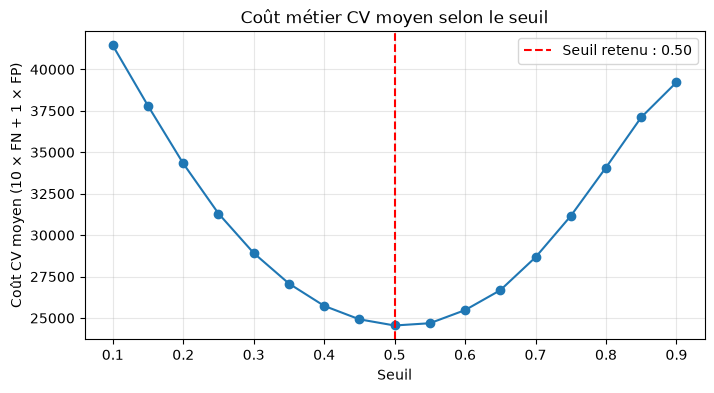

Seuil retenu : 0.50
Coût métier CV moyen : 24,550


In [7]:
# ---------- Courbe CV de la meilleure combinaison ----------
# On récupère uniquement les résultats correspondant
# à la meilleure combinaison d'hyperparamètres trouvée précédemment.
best_combination_id = int(best_result["combination_id"])

threshold_results = (
    threshold_cv_results[
        threshold_cv_results["combination_id"].eq(best_combination_id)
    ]
    [["threshold", "cv_business_cost_mean"]]
    .sort_values("threshold")
)


# ---------- Visualisation du coût selon le seuil ----------
# Le graphique montre comment évolue le coût métier moyen
# quand on change le seuil de décision.
_, cost_axis = plt.subplots(figsize=(8, 4))

cost_axis.plot(
    threshold_results["threshold"],
    threshold_results["cv_business_cost_mean"],
    marker="o",
)


# ---------- Mise en évidence du seuil retenu ----------
# La ligne rouge indique le seuil ayant obtenu
# le coût métier moyen le plus faible pendant la CV.
cost_axis.axvline(
    BEST_THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Seuil retenu : {BEST_THRESHOLD:.2f}",
)

cost_axis.set(
    title="Coût métier CV moyen selon le seuil",
    xlabel="Seuil",
    ylabel=f"Coût CV moyen ({FN_COST} × FN + {FP_COST} × FP)",
)

cost_axis.legend()
cost_axis.grid(alpha=0.3)

plt.show()


# ---------- Résumé ----------
print(f"Seuil retenu : {BEST_THRESHOLD:.2f}")
print(f"Coût métier CV moyen : {BEST_CV_BUSINESS_COST:,.0f}")

## Évaluation finale et contrôle du surapprentissage

Lors de l'évaluation finale, les performances du modèle sont comparées entre les données d'entraînement et les données finales jamais vues. Un écart important de ROC AUC, recall ou F1-score pourrait indiquer un surapprentissage. L'objectif est de vérifier que le modèle conserve des performances comparables en généralisation.

Les nombres bruts de FN, FP et le coût métier ne sont pas directement comparables entre les deux jeux, car l'ensemble d'entraînement contient davantage de lignes. Ils restent affichés pour comprendre les erreurs produites dans chaque ensemble.

,roc_auc,recall,f1_score,fn,fp,tn,tp,business_cost
train,0.838163,0.777834,0.325556,4412,59590,166559,15447,103710
final,0.778149,0.684189,0.289242,1568,15127,41410,3397,30807


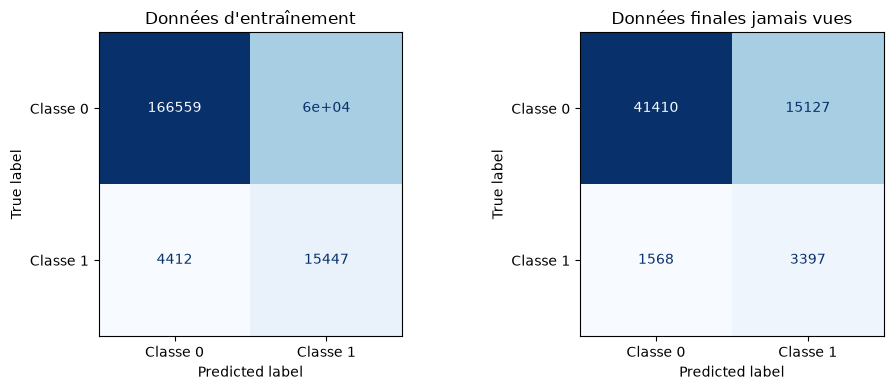

In [8]:
# ---------- Prédictions train et final ----------
train_scores = optimized_model.predict_proba(X_train_selected)[:, 1]
final_scores = optimized_model.predict_proba(X_final_selected)[:, 1]

train_predictions = (train_scores >= BEST_THRESHOLD).astype(int)
final_predictions = (final_scores >= BEST_THRESHOLD).astype(int)

# ---------- Comparaison des performances ----------
train_metrics = evaluate_predictions(
    y_train, train_predictions, train_scores
)
final_metrics = evaluate_predictions(
    y_final, final_predictions, final_scores
)

# ---------- Matrices de confusion ----------
_, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_predictions,
    labels=[0, 1],
    display_labels=["Classe 0", "Classe 1"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Données d'entraînement")

ConfusionMatrixDisplay.from_predictions(
    y_final,
    final_predictions,
    labels=[0, 1],
    display_labels=["Classe 0", "Classe 1"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Données finales jamais vues")

plt.tight_layout()
plt.show()

## Importance des variables du modèle final

L'importance par gain mesure la contribution globale de chaque variable aux arbres de LightGBM. Elle permet d'identifier les variables les plus utiles et de vérifier si les variables issues du feature engineering participent aux décisions du modèle. Elle ne donne cependant ni le sens de l'effet ni une relation causale.

,feature,importance,importance_percent
0,EXT_SOURCE_2,302264.965212,18.120540
1,EXT_SOURCE_3,269343.026632,16.146896
2,EXT_SOURCE_1,100866.898384,6.046889
3,PREV_INSTAL_LATE_PAYMENT_RATIO_MEAN,53317.706224,3.196353
4,DAYS_EMPLOYED,45337.412560,2.717941
5,AMT_CREDIT,41222.684553,2.471267
6,AMT_ANNUITY,37797.231638,2.265913
7,DAYS_BIRTH,37646.437033,2.256873
8,PREV_APPROVED_CREDIT_TO_APPLICATION_RATIO_MEAN,36102.813404,2.164334
9,PREV_APPROVED_CREDIT_SUM,31939.170118,1.914727


Variables avec une importance nulle : 72


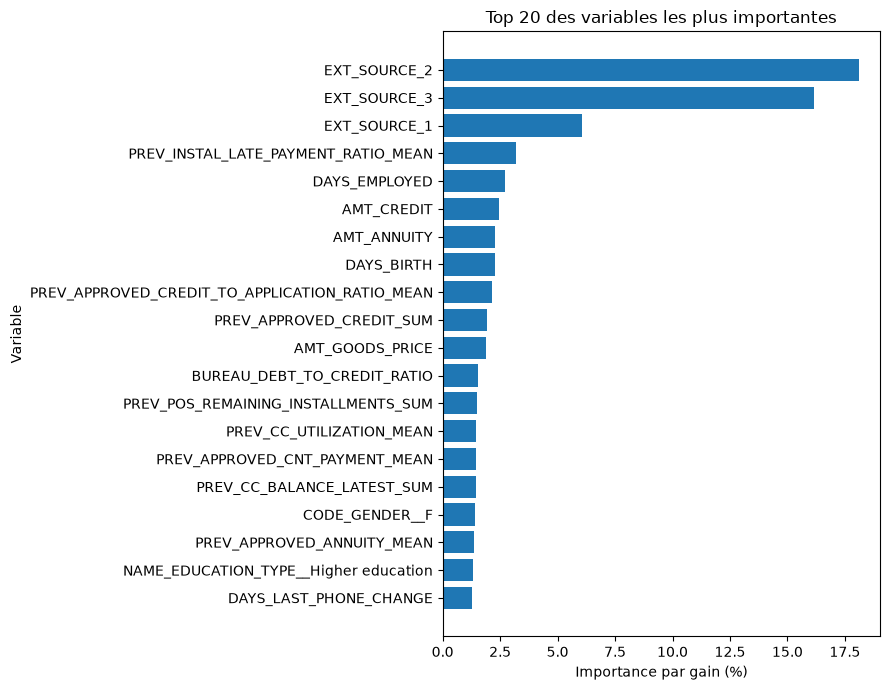

In [9]:
# ---------- Importance des variables ----------
final_classifier = optimized_model.named_steps["classifier"]

feature_importance = (
    pd.DataFrame({
        "feature": X_train_selected.columns,
        "importance": final_classifier.booster_.feature_importance(
            importance_type="gain"
        ),
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
feature_importance["importance_percent"] = (
    100 * feature_importance["importance"]
    / feature_importance["importance"].sum()
)

display(feature_importance.head(20))
print(
    "Variables avec une importance nulle :",
    feature_importance["importance"].eq(0).sum(),
)

# ---------- Variables les plus importantes ----------
top_features = feature_importance.head(20).sort_values("importance_percent")
feature_importance_figure, axis = plt.subplots(figsize=(9, 7))
axis.barh(top_features["feature"], top_features["importance_percent"])
axis.set(
    title="Top 20 des variables les plus importantes",
    xlabel="Importance par gain (%)",
    ylabel="Variable",
)
plt.tight_layout()
plt.show()

## Tracking MLflow, Model Registry et conclusion

Cette dernière cellule enregistre les résultats déjà calculés, puis sauvegarde le pipeline final dans le Model Registry sous le nom `credit_scoring_lightgbm`. Les métriques `cv_*` utilisent les mêmes noms que les runs de sélection des datasets afin de permettre leur comparaison dans MLflow. Les métriques `final_*` concernent uniquement les données finales jamais vues.

In [11]:
# ---------- Tracking MLflow final ----------
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("credit_scoring")

with mlflow.start_run(run_name="lightgbm_optimized_final"):
    mlflow.set_tags({
        "stage": "final_optimization",
        "objective": "business_cost",
        "weighting": "balanced",
        "description": "LightGBM optimisé avec GridSearchCV et seuil métier",
    })

    mlflow.log_params({
        **BEST_GRID_PARAMS,
        "dataset_version": BEST_DATASET_VERSION,
        "n_features": X_train_selected.shape[1],
        "best_threshold": BEST_THRESHOLD,
        "cv_folds": CV.get_n_splits(),
        "cost_fn": FN_COST,
        "cost_fp": FP_COST,
    })

    mlflow.log_metrics({
        **OPTIMIZED_CV_METRICS,
        "final_business_cost": final_metrics["business_cost"],
        "final_fn": final_metrics["fn"],
        "final_fp": final_metrics["fp"],
        "final_tn": final_metrics["tn"],
        "final_tp": final_metrics["tp"],
        "final_recall": final_metrics["recall"],
        "final_f1_score": final_metrics["f1_score"],
        "final_roc_auc": final_metrics["roc_auc"],
    })
    mlflow.log_figure(
        feature_importance_figure,
        "feature_importance_top20.png",
    )
    mlflow.sklearn.log_model(
        sk_model=optimized_model,
        name="model",
        input_example=X_train_selected.head(5),
        registered_model_name="credit_scoring_lightgbm",
        serialization_format="cloudpickle",
    )

print("Run MLflow enregistré : lightgbm_optimized_final")

2026/09/13 17:57:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\Philippe MAGNE\Documents\3 - DEV\P6_initiez_vous_au_MLOps_(partie1_sur_2)\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (floa

Run MLflow enregistré : lightgbm_optimized_final


Successfully registered model 'credit_scoring_lightgbm'.
Created version '1' of model 'credit_scoring_lightgbm'.


## Conclusion

La comparaison des cinq versions du dataset a retenu `without_bureau_dpd_columns`, composée de 310 variables. Avec le LightGBM de référence, elle obtient le coût métier moyen le plus faible (`24 659,6`) et présente une meilleure stabilité que le dataset original. Les deux indicateurs BUREAU supprimés n'amélioraient donc pas la généralisation du modèle.

L'optimisation a ensuite comparé 16 configurations LightGBM et 17 seuils par validation croisée stratifiée à 5 folds. Le meilleur couple est :

- `n_estimators = 300` ;
- `learning_rate = 0.05` ;
- `num_leaves = 31` ;
- `min_child_samples = 20` ;
- seuil métier : `0.50`.

Ce paramétrage atteint un coût métier moyen de `24 550,4` en validation croisée. Le seuil optimal reste égal à 0,50 : dans cette recherche, le paramétrage du modèle et la pondération des classes suffisent donc à obtenir le meilleur compromis entre faux négatifs et faux positifs.

Sur les 61 502 données finales jamais vues, le modèle obtient :

- coût métier : `30 807` ;
- faux négatifs : `1 568` ;
- faux positifs : `15 127` ;
- recall de la classe 1 : `0,684` ;
- F1-score : `0,289` ;
- ROC AUC : `0,778`.

Le ROC AUC passe de `0,838` sur l'entraînement à `0,778` sur les données finales, tandis que le recall passe de `0,778` à `0,684`. Cet écart révèle un surapprentissage modéré : le modèle généralise correctement, mais ses performances sont moins élevées sur des clients jamais vus. Les coûts bruts train/final ne doivent pas être comparés directement, car les deux ensembles n'ont pas la même taille.

L'importance des variables montre que `EXT_SOURCE_2`, `EXT_SOURCE_3` et `EXT_SOURCE_1` dominent les décisions. Des variables issues des jointures, notamment `PREV_INSTAL_LATE_PAYMENT_RATIO_MEAN`, apparaissent aussi parmi les plus importantes : l'historique de paiement apporte donc une information utile au modèle. En revanche, 72 variables ont une importance nulle et pourront être étudiées ultérieurement, sans suppression automatique.

Enfin, le pipeline complet a été enregistré dans MLflow et ajouté au Model Registry sous le nom `credit_scoring_lightgbm`, version 1. Le modèle est ainsi traçable et réutilisable avec son preprocessing.